In [1]:
import matplotlib.pyplot as plt
import numpy as np
from waveguide_mode_solver import guided_modes_1DTE as gm_1D
from waveguide_mode_solver import guided_modes_2D as gm_2D

In [2]:
#global parameters
lam = 0.78
k0 = 2*np.pi/lam
e_substrate = 2.25
delta_e = 1.5e-2
w = 15.0

## 1D Finite Difference Mode Solver

Simulates guided TE modes in a 1D planar waveguide via finite difference discretization of the eigenvalue equation:

$$L = \frac{1}{k_0^2}\frac{d^2}{dx^2}+\varepsilon(x)$$

The second derivative is approximated by a symmetric finite difference scheme, yielding a tridiagonal matrix. Guided modes satisfy:

$$\varepsilon_\mathrm{substrate} < \varepsilon_\mathrm{eff} < \max\bigl(\varepsilon(x)\bigr)$$

**Parameters:** $\lambda = 0.78\mu\mathrm{m}$, $\varepsilon_\mathrm{sub} = 2.25$, Gaussian index profile ($W = 15\mu\mathrm{m}$, $\Delta\varepsilon = 1.5\times10^{-2}$), grid of 601 points over 120 µm.

In [3]:
# Test parameters for Task 1 (length unit in µm)
grid_size = 120
number_points = 601
h = grid_size/(number_points - 1)
xx = np.linspace( -grid_size/2, grid_size/2, number_points )
prm = e_substrate + delta_e * np.exp(-(xx/w)**2)

In [4]:
eff_eps, guided = gm_1D(prm, k0, h)

e_max = prm.max()
idx = (eff_eps < e_max) & (eff_eps > e_substrate)
eff_eps = eff_eps[idx]

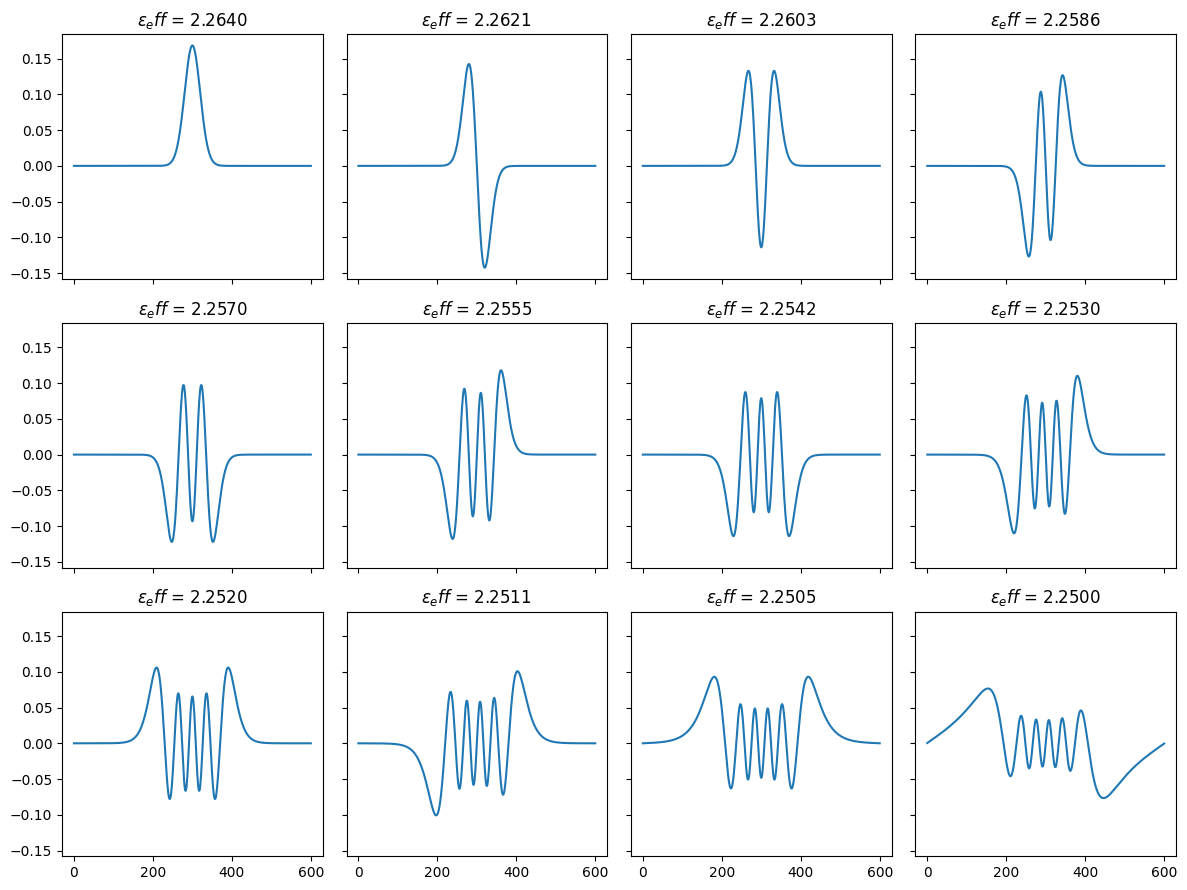

In [5]:
fig, axes = plt.subplots(3, 4, figsize=(12, 9), sharex='all', sharey='all')
for i, ax in enumerate(axes.flatten()):
      ax.plot(guided[:,idx][:,i])
      ax.set_title(r'$\varepsilon_eff$ = %.4f'%eff_eps[i])
plt.tight_layout()

## 2D Finite Difference Mode Solver

Extends to 2D, solving the scalar Helmholtz eigenvalue problem:

$$\left[\frac{\partial^2}{\partial x^2}+\frac{\partial^2}{\partial y^2}+k_0^2\varepsilon(x,y)\right]u(x,y)=\beta^2 u(x,y)$$

Both spatial derivatives are approximated by symmetric finite differences. The 2D field $u_{j,k}$ is unfolded into a 1D vector, and the resulting sparse Laplace operator (>90,000×90,000, ~0.0055% nonzero) is assembled with `scipy.sparse`. The 10 largest eigenvalues and corresponding modes are computed via sparse eigensolver and reshaped back to 2D.

In [6]:
#2D Example Parameters
grid_size = 120
number_points = 301
numb = 10
h = grid_size/(number_points - 1)
xx = np.linspace(-grid_size/2-h,grid_size/2+h,number_points+2)
yy = np.linspace(-grid_size/2,grid_size/2,number_points)
XX,YY = np.meshgrid(xx,yy)
prm = e_substrate + delta_e * np.exp(-(XX**2+YY**2)/w**2)
eff_eps2d, guided2d = gm_2D(prm, k0, h, numb)

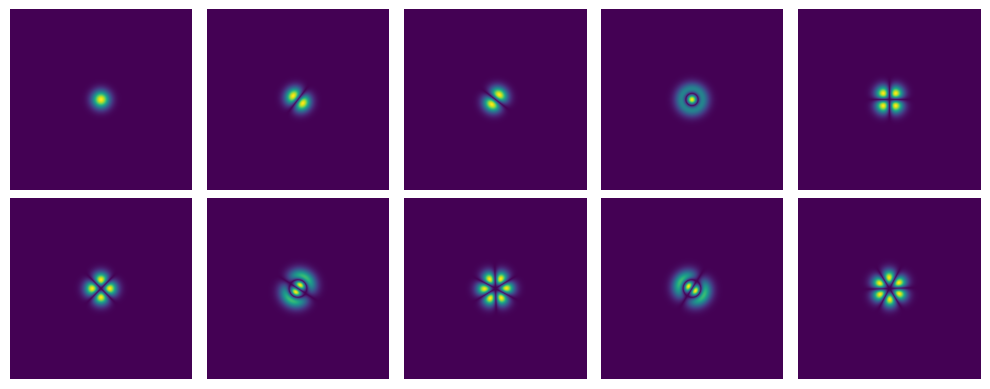

In [7]:
fig, axes = plt.subplots(2, 5, figsize=(10, 4))
for i, ax in zip(range(10), axes.flatten()):
      ax.imshow(np.abs(guided2d[i]))
      ax.axis('off')
plt.tight_layout()